# Analysis Notebook

Raw computations, tables, and figures backing `report/report.pdf`.
Narrative and interpretation live in the report; this notebook holds only
the data pipeline and outputs.

In [1]:
import csv
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np

REPO_ROOT = Path.cwd().parent if Path.cwd().name == "results" else Path.cwd()
sys.path.insert(0, str(REPO_ROOT / "src"))

from analysis import (
    condition_comparison,
    degradation_trends,
    embedding_accuracy_link,
    load_embedding_distances,
    load_summary,
    per_cell_intervals,
    wilson_interval,
)

# Validated colourblind-safe hues (Okabe-Ito); separation verified in OKLab
# under protanopia/deuteranopia/tritanopia simulation before use.
C_MM, C_DICTA, C_MUTED = "#0072B2", "#D55E00", "#9A9A9A"
MODEL_COLOR = {"mmBERT": C_MM, "dictabert": C_DICTA}
LEVELS = [0, 30, 60, 100]

plt.rcParams.update({
    "figure.dpi": 150, "savefig.dpi": 200, "savefig.bbox": "tight",
    "font.size": 10, "axes.titlesize": 11, "axes.labelsize": 10,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.alpha": 0.25, "grid.linewidth": 0.6,
    "legend.frameon": False,
})

FIG_DIR = REPO_ROOT / "results" / "figures"
rows = load_summary()
distances = load_embedding_distances()
cells = per_cell_intervals(rows)
print(f"loaded {len(rows)} result cells, {len(distances)} embedding distance points")

loaded 16 result cells, 18 embedding distance points


## 1. Dataset and provenance

In [2]:
final = list(csv.DictReader(open(REPO_ROOT / "data" / "final" / "dataset_final.csv", encoding="utf-8")))
from collections import Counter

print(f"dataset_final.csv: {len(final)} rows, {len({r['id'].rsplit('_', 1)[0] for r in final})} seeds")
print("sentiment:", dict(Counter(r["sentiment"] for r in final)))
print("mixing level:", dict(Counter(r["mixing_level"] for r in final)))

for name in ("train", "val", "test"):
    split = list(csv.DictReader(open(REPO_ROOT / "data" / "final" / f"{name}.csv", encoding="utf-8")))
    seeds = {r["id"].rsplit("_", 1)[0] for r in split}
    print(f"{name:>5}: {len(split):>3} rows, {len(seeds):>2} seeds, "
          f"sentiment={dict(Counter(r['sentiment'] for r in split))}")

dataset_final.csv: 420 rows, 105 seeds
sentiment: {'positive': 136, 'negative': 196, 'neutral': 88}
mixing level: {'0': 105, '100': 105, '30': 105, '60': 105}
train: 292 rows, 73 seeds, sentiment={'negative': 136, 'neutral': 60, 'positive': 96}
  val:  64 rows, 16 seeds, sentiment={'negative': 28, 'positive': 20, 'neutral': 16}
 test:  64 rows, 16 seeds, sentiment={'negative': 32, 'positive': 20, 'neutral': 12}


## 2. Annotation agreement

In [3]:
from sklearn.metrics import cohen_kappa_score

r1 = {r["id"]: r["reviewer1_sentiment"]
      for r in csv.DictReader(open(REPO_ROOT / "data/annotated/reviewer1_annotations.csv", encoding="utf-8"))}
r2 = {r["id"]: r["reviewer2_sentiment"]
      for r in csv.DictReader(open(REPO_ROOT / "data/annotated/reviewer2_annotations.csv", encoding="utf-8"))}
intended = {r["id"]: r["intended_sentiment"]
            for r in csv.DictReader(open(REPO_ROOT / "data/generated/dataset_raw.csv", encoding="utf-8"))}

ids = list(r1)
kappa = cohen_kappa_score([r1[i] for i in ids], [r2[i] for i in ids],
                          labels=["positive", "neutral", "negative"])
acc1 = np.mean([r1[i] == intended[i] for i in ids])
acc2 = np.mean([r2[i] == intended[i] for i in ids])

print(f"Cohen's kappa, reviewer1 (human) vs reviewer2 (LLM): {kappa:.4f}")
print(f"reviewer1 (human) vs intended_sentiment: {acc1:.3f}")
print(f"reviewer2 (LLM)   vs intended_sentiment: {acc2:.3f}")
print()
print("Only 2 of 105 seeds drew any annotator disagreement with the intended")
print("label at all — the corpus encodes sentiment unusually unambiguously.")
print("That is a limitation of the corpus, discussed in section 8.")

Cohen's kappa, reviewer1 (human) vs reviewer2 (LLM): 0.9849
reviewer1 (human) vs intended_sentiment: 0.981
reviewer2 (LLM)   vs intended_sentiment: 0.990

Only 2 of 105 seeds drew any annotator disagreement with the intended
label at all — the corpus encodes sentiment unusually unambiguously.
That is a limitation of the corpus, discussed in section 8.


## 3. Embedding geometry

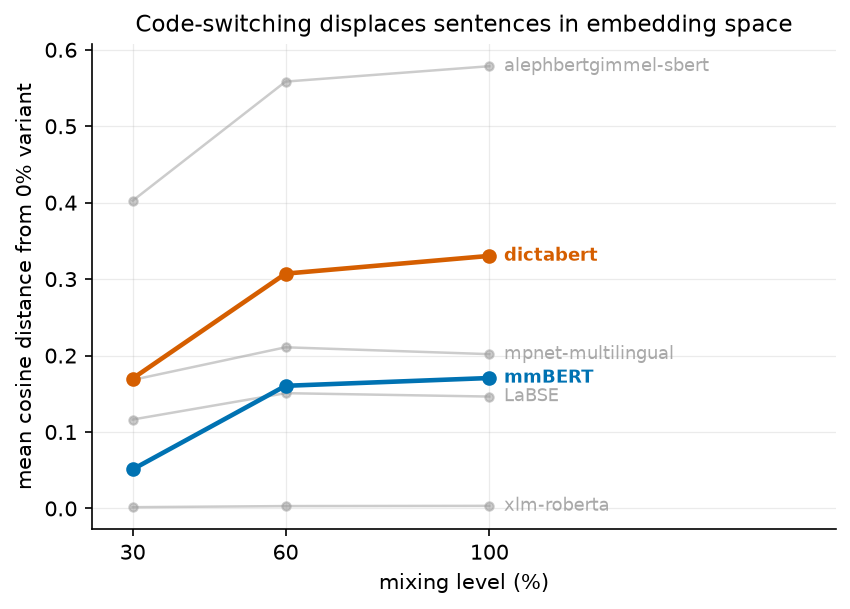

                  mmBERT: 30%=0.051  60%=0.160  100%=0.171
               dictabert: 30%=0.170  60%=0.307  100%=0.330
             xlm-roberta: 30%=0.002  60%=0.003  100%=0.003
      mpnet-multilingual: 30%=0.168  60%=0.211  100%=0.202
                   LaBSE: 30%=0.116  60%=0.151  100%=0.146
   alephbertgimmel-sbert: 30%=0.403  60%=0.558  100%=0.579


In [4]:
emb_models = ["mmBERT", "dictabert", "xlm-roberta", "mpnet-multilingual", "LaBSE", "alephbertgimmel-sbert"]
fig, ax = plt.subplots(figsize=(6.4, 4.2))

# Every series is direct-labelled at its right endpoint: the four context
# models share one grey, so a legend could not tell them apart.
endpoints = sorted(emb_models, key=lambda m: distances.get((m, "100"), 0))
nudge = {m: 0.0 for m in emb_models}
for prev, cur in zip(endpoints, endpoints[1:]):
    gap = distances.get((cur, "100"), 0) - distances.get((prev, "100"), 0)
    if gap < 0.022:
        nudge[cur] = nudge[prev] + (0.022 - gap)

for m in emb_models:
    ys = [distances.get((m, str(l)), np.nan) for l in [30, 60, 100]]
    highlighted = m in MODEL_COLOR
    color = MODEL_COLOR.get(m, C_MUTED)
    ax.plot([30, 60, 100], ys, marker="o", markersize=6 if highlighted else 4,
            linewidth=2.2 if highlighted else 1.2, color=color,
            alpha=1.0 if highlighted else 0.5, zorder=3 if highlighted else 2)
    ax.annotate(m, (100, ys[-1] + nudge[m]), textcoords="offset points", xytext=(7, 0),
                color=color, alpha=1.0 if highlighted else 0.85,
                fontweight="bold" if highlighted else "normal",
                va="center", fontsize=8.5)

ax.set_xlabel("mixing level (%)")
ax.set_ylabel("mean cosine distance from 0% variant")
ax.set_title("Code-switching displaces sentences in embedding space")
ax.set_xticks([30, 60, 100])
ax.set_xlim(22, 168)
fig.savefig(FIG_DIR / "fig1_embedding_drift.png")
plt.show()

for m in emb_models:
    print(f"  {m:>22}: " + "  ".join(f"{l}%={distances.get((m, str(l)), float('nan')):.3f}" for l in [30, 60, 100]))

## 4. Fine-tuning results

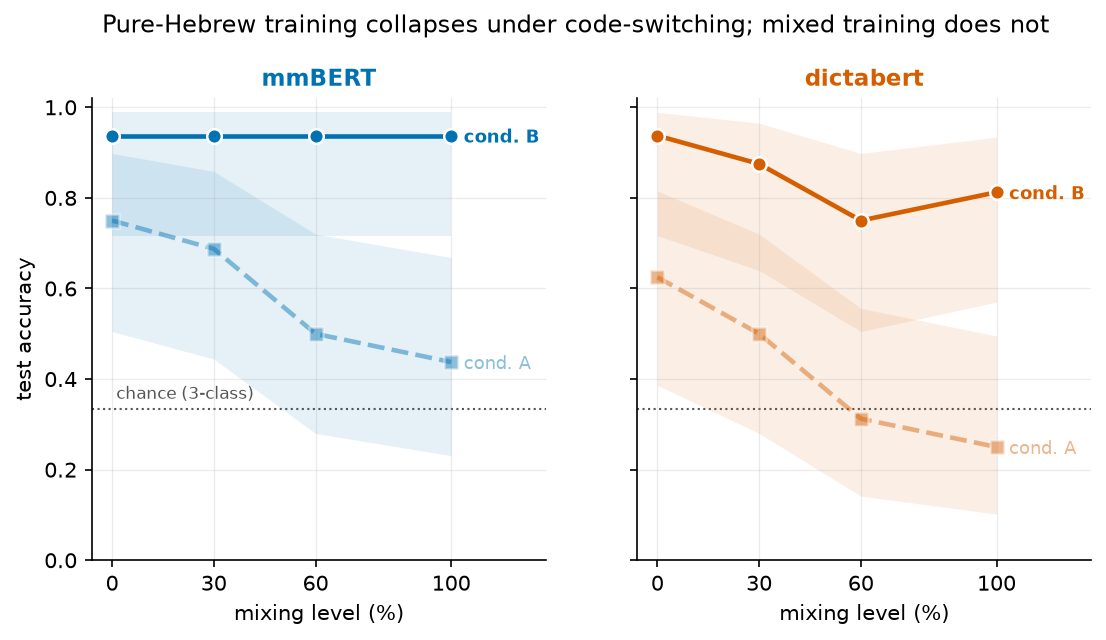

Shaded bands are 95% Wilson intervals. n=16 per cell — the bands are wide,
and most single-cell differences are NOT individually separable.


In [5]:
# Faceted as small multiples: four overlapping CI bands on one axis turn to
# mud, so each model gets its own panel with a shared y-axis.
fig, axes = plt.subplots(1, 2, figsize=(8.6, 4.0), sharey=True)

for ax, model in zip(axes, ["mmBERT", "dictabert"]):
    color = MODEL_COLOR[model]
    for cond, ls, marker, alpha in [("A", "--", "s", 0.45), ("B", "-", "o", 1.0)]:
        sub = sorted([c for c in cells if c["model"] == model and c["condition"] == cond],
                     key=lambda r: int(r["mixing_level"]))
        xs = [int(c["mixing_level"]) for c in sub]
        ys = [c["accuracy"] for c in sub]
        ax.fill_between(xs, [c["ci_low"] for c in sub], [c["ci_high"] for c in sub],
                        color=color, alpha=0.10, linewidth=0, zorder=1)
        ax.plot(xs, ys, ls, marker=marker, color=color, linewidth=2.2, markersize=7,
                markeredgecolor="white", markeredgewidth=1.2, alpha=alpha, zorder=3,
                label=f"cond. {cond}")
        ax.annotate(f"cond. {cond}", (100, ys[-1]), textcoords="offset points",
                    xytext=(6, -1), fontsize=8.5, color=color, alpha=alpha,
                    fontweight="bold" if cond == "B" else "normal", va="center")

    ax.axhline(1/3, color="#555555", linewidth=1, linestyle=":", zorder=0)
    ax.set_title(model, color=color, fontweight="bold")
    ax.set_xlabel("mixing level (%)")
    ax.set_xticks(LEVELS)
    ax.set_xlim(-6, 128)
    ax.set_ylim(0, 1.02)

axes[0].set_ylabel("test accuracy")
axes[0].annotate("chance (3-class)", (0, 1/3), textcoords="offset points", xytext=(2, 5),
                 fontsize=8, color="#555555")
fig.suptitle("Pure-Hebrew training collapses under code-switching; mixed training does not",
             fontsize=11.5, y=1.02)
fig.savefig(FIG_DIR / "fig2_accuracy_vs_mixing.png")
plt.show()

print("Shaded bands are 95% Wilson intervals. n=16 per cell — the bands are wide,")
print("and most single-cell differences are NOT individually separable.")

In [6]:
print(f"{'model':>10} {'cond':>5} {'mix':>5} {'acc':>7} {'95% CI':>16}")
print("-" * 48)
for c in cells:
    print(f"{c['model']:>10} {c['condition']:>5} {c['mixing_level']:>4}% "
          f"{c['accuracy']:>7.3f} {'[' + format(c['ci_low'], '.2f') + ', ' + format(c['ci_high'], '.2f') + ']':>16}")

     model  cond   mix     acc           95% CI
------------------------------------------------
    mmBERT     A    0%   0.750     [0.51, 0.90]
    mmBERT     A   30%   0.688     [0.44, 0.86]
    mmBERT     A   60%   0.500     [0.28, 0.72]
    mmBERT     A  100%   0.438     [0.23, 0.67]
    mmBERT     B    0%   0.938     [0.72, 0.99]
    mmBERT     B   30%   0.938     [0.72, 0.99]
    mmBERT     B   60%   0.938     [0.72, 0.99]
    mmBERT     B  100%   0.938     [0.72, 0.99]
 dictabert     A    0%   0.625     [0.39, 0.82]
 dictabert     A   30%   0.500     [0.28, 0.72]
 dictabert     A   60%   0.312     [0.14, 0.56]
 dictabert     A  100%   0.250     [0.10, 0.49]
 dictabert     B    0%   0.938     [0.72, 0.99]
 dictabert     B   30%   0.875     [0.64, 0.97]
 dictabert     B   60%   0.750     [0.51, 0.90]
 dictabert     B  100%   0.812     [0.57, 0.93]


## 5. Statistical tests

In [7]:
print("A vs B, pooled across mixing levels (n=64 per condition), Fisher exact:")
for c in condition_comparison(rows):
    print(f"  {c['model']:>10}: A={c['acc_A']:.3f} [{c['ci_A'][0]:.2f}, {c['ci_A'][1]:.2f}]   "
          f"B={c['acc_B']:.3f} [{c['ci_B'][0]:.2f}, {c['ci_B'][1]:.2f}]   p={c['p_fisher']:.2e}")

print()
print("Degradation trend across mixing level (Cochran-Armitage):")
for t in degradation_trends(rows):
    verdict = "SIGNIFICANT" if t["p_trend"] < 0.05 else "not significant"
    print(f"  {t['model']:>10} cond {t['condition']}: z={t['z']:+.3f}  p={t['p_trend']:.4f}  ({verdict})")

A vs B, pooled across mixing levels (n=64 per condition), Fisher exact:
   dictabert: A=0.422 [0.31, 0.54]   B=0.844 [0.74, 0.91]   p=1.14e-06
      mmBERT: A=0.594 [0.47, 0.71]   B=0.938 [0.85, 0.98]   p=5.44e-06

Degradation trend across mixing level (Cochran-Armitage):
   dictabert cond A: z=-2.343  p=0.0191  (SIGNIFICANT)
   dictabert cond B: z=-1.163  p=0.2448  (not significant)
      mmBERT cond A: z=-2.029  p=0.0424  (SIGNIFICANT)
      mmBERT cond B: z=+0.000  p=1.0000  (not significant)


## 6. Embedding drift vs. accuracy loss

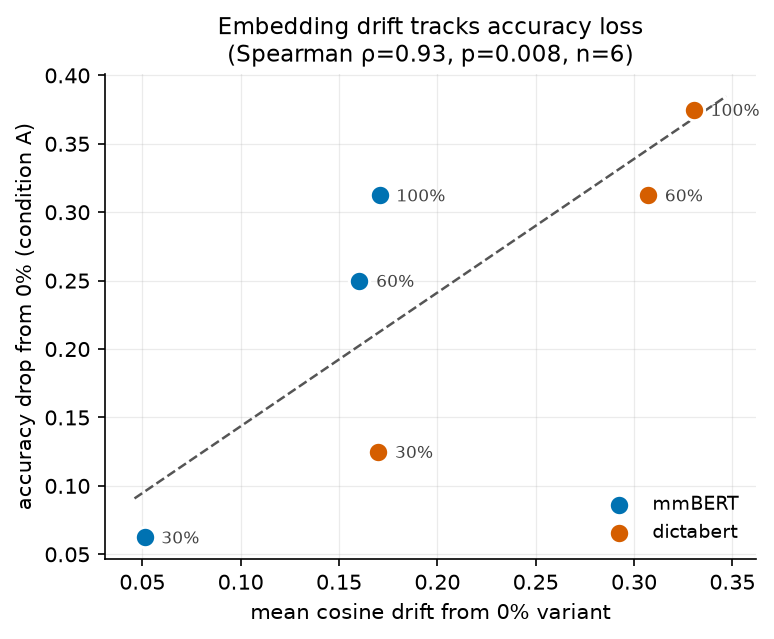

Caveat: 6 paired points from 2 models. Descriptive, not a powered test —
but the ordering is consistent, and it is corroborated by the independent
fact that the model which drifts more (DictaBERT) also degrades more.


In [8]:
from scipy import stats

link = embedding_accuracy_link(rows, distances)
fig, ax = plt.subplots(figsize=(5.6, 4.2))

for model in ["mmBERT", "dictabert"]:
    pts = [r for r in link if r["model"] == model]
    ax.scatter([p["cosine_drift"] for p in pts], [p["accuracy_drop"] for p in pts],
               s=95, color=MODEL_COLOR[model], edgecolor="white", linewidth=1.4,
               zorder=3, label=model)
    for p in pts:
        ax.annotate(f"{p['mixing_level']}%", (p["cosine_drift"], p["accuracy_drop"]),
                    textcoords="offset points", xytext=(8, -3), fontsize=8, color="#444444")

xs = np.array([r["cosine_drift"] for r in link])
ys = np.array([r["accuracy_drop"] for r in link])
slope, intercept = np.polyfit(xs, ys, 1)
grid = np.linspace(xs.min() * 0.9, xs.max() * 1.05, 50)
ax.plot(grid, slope * grid + intercept, color="#555555", linewidth=1.2, linestyle="--", zorder=2)

rho, p_rho = stats.spearmanr(xs, ys)
ax.set_xlabel("mean cosine drift from 0% variant")
ax.set_ylabel("accuracy drop from 0% (condition A)")
ax.set_title(f"Embedding drift tracks accuracy loss\n(Spearman ρ={rho:.2f}, p={p_rho:.3f}, n={len(link)})")
ax.legend(fontsize=9, loc="lower right")
fig.savefig(FIG_DIR / "fig3_drift_vs_accuracy.png")
plt.show()

print("Caveat: 6 paired points from 2 models. Descriptive, not a powered test —")
print("but the ordering is consistent, and it is corroborated by the independent")
print("fact that the model which drifts more (DictaBERT) also degrades more.")

## 7. Semantic equivalence check

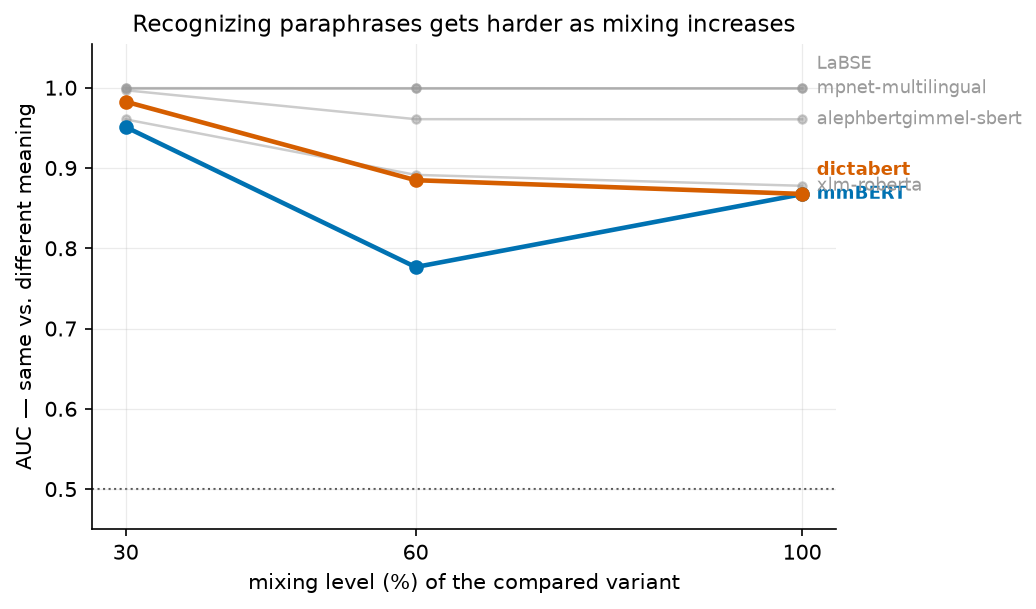

                  mmBERT: 30%=0.951  60%=0.777  100%=0.867
               dictabert: 30%=0.983  60%=0.885  100%=0.868
             xlm-roberta: 30%=0.961  60%=0.891  100%=0.878
      mpnet-multilingual: 30%=0.999  60%=0.999  100%=0.999
                   LaBSE: 30%=1.000  60%=1.000  100%=1.000
   alephbertgimmel-sbert: 30%=0.997  60%=0.961  100%=0.961


In [9]:
sem_rows = list(csv.DictReader(open(REPO_ROOT / "results" / "semantic_equivalence.csv", encoding="utf-8")))
for r in sem_rows:
    r["auc"] = float(r["auc"])

sem_models = list(dict.fromkeys(r["model"] for r in sem_rows))
fig, ax = plt.subplots(figsize=(6.4, 4.2))

final_auc = {r["model"]: r["auc"] for r in sem_rows if r["mixing_level"] == "100"}
order = sorted(sem_models, key=lambda m: final_auc[m])
nudge = {m: 0.0 for m in sem_models}
for prev, cur in zip(order, order[1:]):
    gap = final_auc[cur] - final_auc[prev] + nudge[prev]
    if gap < 0.03:
        nudge[cur] = nudge[prev] + (0.03 - gap)

for m in sem_models:
    highlighted = m in MODEL_COLOR
    color = MODEL_COLOR.get(m, C_MUTED)
    sub = [r for r in sem_rows if r["model"] == m]
    xs = [int(r["mixing_level"]) for r in sub]
    ys = [r["auc"] for r in sub]
    ax.plot(xs, ys, marker="o", markersize=6 if highlighted else 4,
            linewidth=2.2 if highlighted else 1.2, color=color,
            alpha=1.0 if highlighted else 0.5, zorder=3 if highlighted else 2)
    ax.annotate(m, (100, ys[-1] + nudge[m]), textcoords="offset points", xytext=(7, 0),
                color=color, fontweight="bold" if highlighted else "normal", va="center", fontsize=8.5)

ax.axhline(0.5, color="#555555", linewidth=1, linestyle=":", zorder=0)
ax.set_xlabel("mixing level (%) of the compared variant")
ax.set_ylabel("AUC — same vs. different meaning")
ax.set_title("Recognizing paraphrases gets harder as mixing increases")
ax.set_xticks([30, 60, 100])
top = max(1.02, max(final_auc[m] + nudge[m] for m in sem_models) + 0.025)
ax.set_ylim(0.45, top)
fig.savefig(FIG_DIR / "fig4_semantic_equivalence.png")
plt.show()

for m in sem_models:
    sub = [r for r in sem_rows if r["model"] == m]
    print(f"  {m:>22}: " + "  ".join(f"{r['mixing_level']}%={r['auc']:.3f}" for r in sub))

## 8. Annotator baseline

In [10]:
baseline = list(csv.DictReader(open(REPO_ROOT / "results" / "human_baseline.csv", encoding="utf-8")))
print(f"{'mix':>5} {'n':>4} {'human':>8} {'LLM':>8}")
print("-" * 28)
for b in baseline:
    print(f"{b['mixing_level']:>4}% {b['n']:>4} {float(b['reviewer1_human_accuracy']):>8.3f} "
          f"{float(b['reviewer2_llm_accuracy']):>8.3f}")

print()
print("Both annotators score 100% at every mixing level on the test split.")
print("This is a REAL measurement but a weak ceiling: only 2 of 105 seeds drew")
print("any annotator error corpus-wide, and both fell in the training split.")
print("It says the corpus is unambiguous, not that the task is trivial in the wild.")

  mix    n    human      LLM
----------------------------
   0%   16    1.000    1.000
  30%   16    1.000    1.000
  60%   16    1.000    1.000
 100%   16    1.000    1.000

Both annotators score 100% at every mixing level on the test split.
This is a REAL measurement but a weak ceiling: only 2 of 105 seeds drew
any annotator error corpus-wide, and both fell in the training split.
It says the corpus is unambiguous, not that the task is trivial in the wild.
